## 1. IMPORTING LIBRARIES

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. IMPORT CSV AND READ IT

In [2]:
df = pd.read_csv("ecommerce_raw.csv")
df.head()

,order_id,customer_id,customer_name,email,order_date,ship_date,product_id,product_name,category,region,city,quantity,unit_price,discount,revenue,payment_method,customer_segment,rating
0,ORD001000,CUST00179,William Villanueva,lewischristopher@example.org,2023-10-09,2023-10-13,PROD674,Persevering optimal methodology,Electronics,North,Chicago,2.0,407.64,0.10,733.75,credit card,Returning,4.0
1,ORD001001,CUST00866,Juan Lambert,kimberlyhendrix@example.net,2024-08-26,2024-08-31,PROD199,Business-focused well-modulated open architecture,Books,South,New Orleans,1.0,456.49,0.00,456.49,PayPal,Returning,NaN
2,ORD001002,CUST00741,Karen Carroll,whitney52@example.com,2024-07-03,NaN,PROD181,Synchronized responsive project,home & garden,North,Milwaukee,7.0,51.89,0.00,363.23,PAYPAL,New,3.0
3,ORD001003,CUST00147,Rebecca Hanson,rfranklin@example.org,2023-06-16,2023-06-22,PROD755,Optional didactic framework,Clothing,West,Seattle,5.0,422.58,0.15,1795.96,Debit Card,Returning,NaN
4,ORD001004,CUST00645,Derrick Martinez,fphillips@example.net,2023-02-02,2023-02-08,PROD242,Open-architected high-level hierarchy,Clothing,North,Detroit,2.0,130.53,0.10,234.95,NaN,Returning,NaN


## 3. CHECKING THE CSV OUT


*   The shape
*   Checking for `null values`
*   Check for `duplicate items`
*   Check for `Outlier detection`
*   Check `inconsistent categories`
*   coverting `datatypes`






In [8]:
print("Shape of the dataset: ")
df.shape

Shape of the dataset: 


(5080, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5080 entries, 0 to 5079
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5080 non-null   object 
 1   customer_id       5080 non-null   object 
 2   customer_name     5080 non-null   object 
 3   email             4864 non-null   object 
 4   order_date        5080 non-null   object 
 5   ship_date         4844 non-null   object 
 6   product_id        5080 non-null   object 
 7   product_name      5080 non-null   object 
 8   category          5080 non-null   object 
 9   region            5080 non-null   object 
 10  city              5080 non-null   object 
 11  quantity          4927 non-null   float64
 12  unit_price        5080 non-null   float64
 13  discount          5080 non-null   float64
 14  revenue           5080 non-null   float64
 15  payment_method    4364 non-null   object 
 16  customer_segment  5080 non-null   object 


In [9]:
print("Checking for the number of null values")
df.isnull().sum()

Checking for the number of null values


,0
order_id,0
customer_id,0
customer_name,0
email,216
order_date,0
ship_date,236
product_id,0
product_name,0
category,0
region,0


In [10]:
#checking duplicated values
df.duplicated().sum()

np.int64(80)

In [20]:
#order_id must be unique check if there are any duplicated order_id
num_duplicated_order_ids = df[df['order_id'].duplicated(keep=False)].shape[0]
print(f"Number of duplicated order_ids: {num_duplicated_order_ids}")

Number of duplicated order_ids: 160


In [13]:
#sort categories
print("Check the diff categories and spot inconsistent categories")
df.category.unique()

Check the diff categories and spot inconsistent categories:


array(['Electronics', 'Books', 'home & garden', 'Clothing',
       'Home & Garden', 'electronics', 'Sports', 'CLOTHING'], dtype=object)

In [19]:
# sort payment methods
print("the different payment methods:")
df.payment_method.unique()

the different payment methods:


array(['credit card', 'PayPal', 'PAYPAL', 'Debit Card', nan, 'Apple Pay',
       'Credit Card'], dtype=object)

## 4. REMOVING DUPLICATE VALUES

In [25]:
#THE ORDER_ID MUST REMAIN UNIQUE
df.drop_duplicates(subset = ["order_id"], inplace= True)
print("Now the number of rows left is: ", df.shape)

Now the number of rows left is:  (5000, 18)


## 5. DEALING WITH INCONSISTENCIES IN DATA

In [28]:
# INCONSISTENT CATEGORIES
df.category.replace("electronics", "Electronics", inplace =True)
df.category.replace("CLOTHING", "Clothing", inplace = True)
df.category.replace("home & garden", "Home & Garden", inplace = True)
print("Cleaned and sorted categories: ", df.category.unique())

Cleaned and sorted categories:  ['Electronics' 'Books' 'Home & Garden' 'Clothing' 'Sports']


In [36]:
# INCONSISTENT PAYMENT METHODS

df.payment_method.replace("credit card", "Credit Card", inplace = True)
df.payment_method.replace("PAYPAL","PayPal", inplace = True )
df.payment_method.replace('Paypal', "PayPal", inplace = True)
print("Cleaned and sorted payment methods: ", df.payment_method.unique())

Cleaned and sorted payment methods:  ['Credit Card' 'PayPal' 'Debit Card' nan 'Apple Pay']


## 6.FIX DATE FORMAT (mixed YYYY-MM-DD and DD/MM/YYYY)

In [38]:
df['order_date'] = pd.to_datetime(df['order_date'], infer_datetime_format=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], infer_datetime_format=True, errors='coerce')

print("Date columns converted to datetime format.")


Date columns converted to datetime format.


/tmp/ipykernel_1069/2442426913.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['order_date'] = pd.to_datetime(df['order_date'], infer_datetime_format=True, errors='coerce')
/tmp/ipykernel_1069/2442426913.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['ship_date'] = pd.to_datetime(df['ship_date'], infer_datetime_format=True, errors='coerce')


## 8. DEALING WITH MISSING VALUES

In [39]:
df.isnull().sum()

,0
order_id,0
customer_id,0
customer_name,0
email,215
order_date,42
ship_date,235
product_id,0
product_name,0
category,0
region,0


In [46]:
# filling missing emails with `unknown`
df.email.isnull().sum() # 215 empty values
df.email.fillna("unknown", inplace = True)
print("now that null values are filled :", df.email.isnull().sum())

now that null values are filled : 0


In [76]:
# filling payment method with mode
mode_payment = df["payment_method"].mode()[0]
df["payment_method"] = df["payment_method"].fillna(mode_payment)
print(f"payment_method nulls remaining: {df['payment_method'].isna().sum()}")

payment_method nulls remaining: 0


In [78]:
# filling the quantitiy value with the median of the category
df["quantity"]= df["quantity"].fillna(
    df.groupby("category")["quantity"].transform("mean")
)

In [81]:
#ship_date missing → flag as "unshipped"
df["is_shipped"] = df["ship_date"].notna().astype(int)


In [87]:
# dealing with empty ratings
print("Distribution of 'rating' column:")
display(df['rating'].value_counts(dropna=False))

Distribution of 'rating' column:


,count
rating,
NaN,1451
3.0,760
1.0,737
4.0,724
2.0,668
5.0,660


In [88]:
mode_rating = df['rating'].mode()[0]
df['rating'].fillna(mode_rating, inplace=True)
print(f"Remaining nulls in 'rating' after filling with mode: {df['rating'].isnull().sum()}")

Remaining nulls in 'rating' after filling with mode: 0


/tmp/ipykernel_1069/2082057723.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(mode_rating, inplace=True)


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   object        
 1   customer_id       5000 non-null   object        
 2   customer_name     5000 non-null   object        
 3   email             5000 non-null   object        
 4   order_date        4958 non-null   datetime64[ns]
 5   ship_date         4765 non-null   datetime64[ns]
 6   product_id        5000 non-null   object        
 7   product_name      5000 non-null   object        
 8   category          5000 non-null   object        
 9   region            5000 non-null   object        
 10  city              5000 non-null   object        
 11  quantity          5000 non-null   float64       
 12  unit_price        5000 non-null   float64       
 13  discount          5000 non-null   float64       
 14  revenue           5000 non-nu

In [90]:
#handling order_date null values
# we will drop those 42 values
df.dropna(subset = ["order_date"], inplace = True)
print("no of rows left now: ", df.shape)

no of rows left now:  (4958, 19)


In [95]:
#handling null ship dates
df["Shipping_duration"] = df["ship_date"] - df["order_date"]

mean_shipping_duration = df["Shipping_duration"].dt.days.mean()
print("AVG SHIPPING DURATION: ", mean_shipping_duration)
#convert back to timedelta obj
mean_shipping_duration = pd.to_timedelta(mean_shipping_duration, unit='D')

mask = df['ship_date'].isnull() & df['order_date'].notnull()
df.loc[mask, 'ship_date'] = df.loc[mask, 'order_date'] + mean_shipping_duration

print(f"Remaining nulls in 'ship_date': {df['ship_date'].isnull().sum()}")

# Drop the temporary 'shipping_duration' column as it's no longer needed
df.drop(columns=['Shipping_duration'], inplace=True, errors='ignore')

AVG SHIPPING DURATION:  6.5593650793650795
Remaining nulls in 'ship_date': 0


## 9. DEALING WITH OUTLIERS


In [98]:
Q1 = df["unit_price"].quantile(0.25)
Q3 = df["unit_price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["unit_price"] < lower_bound) | (df["unit_price"] > upper_bound)]
print(f"Price outliers detected: {len(outliers)} rows")
print(f"  Normal range: ${lower_bound:.2f} – ${upper_bound:.2f}")
print(f"  Outlier prices: {sorted(outliers['unit_price'].unique())[:10]}")

# Flag outliers rather than delete
df["is_price_outlier"] = ((df["unit_price"] < lower_bound) | (df["unit_price"] > upper_bound)).astype(int)

# For revenue analysis, exclude outlier orders
df_clean_prices = df[df["is_price_outlier"] == 0].copy()
print(f"  Rows after excluding outliers: {len(df_clean_prices)}")


Price outliers detected: 88 rows
  Normal range: $-302.13 – $912.74
  Outlier prices: [np.float64(5086.5), np.float64(5122.24), np.float64(5757.29), np.float64(6160.18), np.float64(6199.51), np.float64(6747.63), np.float64(6901.19), np.float64(7036.43), np.float64(7056.32), np.float64(7603.04)]
  Rows after excluding outliers: 4870


## 10. SERPERATING RETURN FROM SALES

In [101]:
df["is_return"] = (df["revenue"] < 0).astype(int)
returns = df[df["is_return"] == 1]
sales = df[df["is_return"] == 0]
print(f"Returns: {len(returns)} rows ({len(returns)/len(df):.1%})")
print(f"Sales:   {len(sales)} rows")


Returns: 318 rows (6.4%)
Sales:   4640 rows


##11. FEATURE ENGINEERING

In [102]:
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_quarter"] = df["order_date"].dt.quarter
df["order_month_name"] = df["order_date"].dt.strftime("%b")
df["order_day_of_week"] = df["order_date"].dt.day_name()
df["revenue_per_unit"] = (df["revenue"] / df["quantity"].replace(0, np.nan)).round(2)

# Customer lifetime value proxy
customer_revenue = df[df["is_return"] == 0].groupby("customer_id")["revenue"].sum()
df["customer_ltv"] = df["customer_id"].map(customer_revenue)

print(f"New columns added: order_year, order_month, order_quarter, order_day_of_week,")
print(f"                   revenue_per_unit, customer_ltv")


New columns added: order_year, order_month, order_quarter, order_day_of_week,
                   revenue_per_unit, customer_ltv


## 12. DATATYPE CONSISTENCY

In [103]:
df["quantity"] = df["quantity"].astype(int)
df["discount"] = df["discount"].astype(float)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

## 13. FINAL CHECK BEFORE EXPORTING

In [107]:
print(df.shape)
print(df.columns)

(4958, 28)
Index(['order_id', 'customer_id', 'customer_name', 'email', 'order_date',
       'ship_date', 'product_id', 'product_name', 'category', 'region', 'city',
       'quantity', 'unit_price', 'discount', 'revenue', 'payment_method',
       'customer_segment', 'rating', 'is_shipped', 'is_price_outlier',
       'is_return', 'order_year', 'order_month', 'order_quarter',
       'order_month_name', 'order_day_of_week', 'revenue_per_unit',
       'customer_ltv'],
      dtype='object')


In [109]:
df.to_csv("ecommerce_preprocessed.csv", index=False)


## 14. QUICK VISUALISATIONS

/tmp/ipykernel_1069/827551227.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x =cat_rev.index, y = cat_rev.values, palette = 'viridis')


Text(0, 0.5, 'Total Revenue')

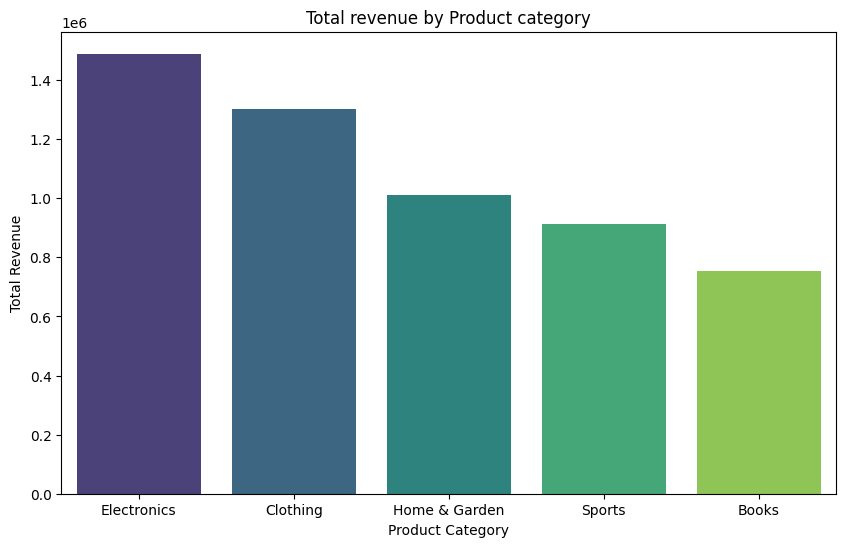

In [118]:
#!. REVENUE BY CATEGORY BAR CHART
cat_rev = df.groupby("category")["revenue"].sum().sort_values(ascending = False)

plt.figure(figsize=(10, 6))
sns.barplot(x =cat_rev.index, y = cat_rev.values, palette = 'viridis')
plt.title("Total revenue by Product category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

### 2. Monthly Revenue Trend

/tmp/ipykernel_1069/1123492494.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', palette='viridis')


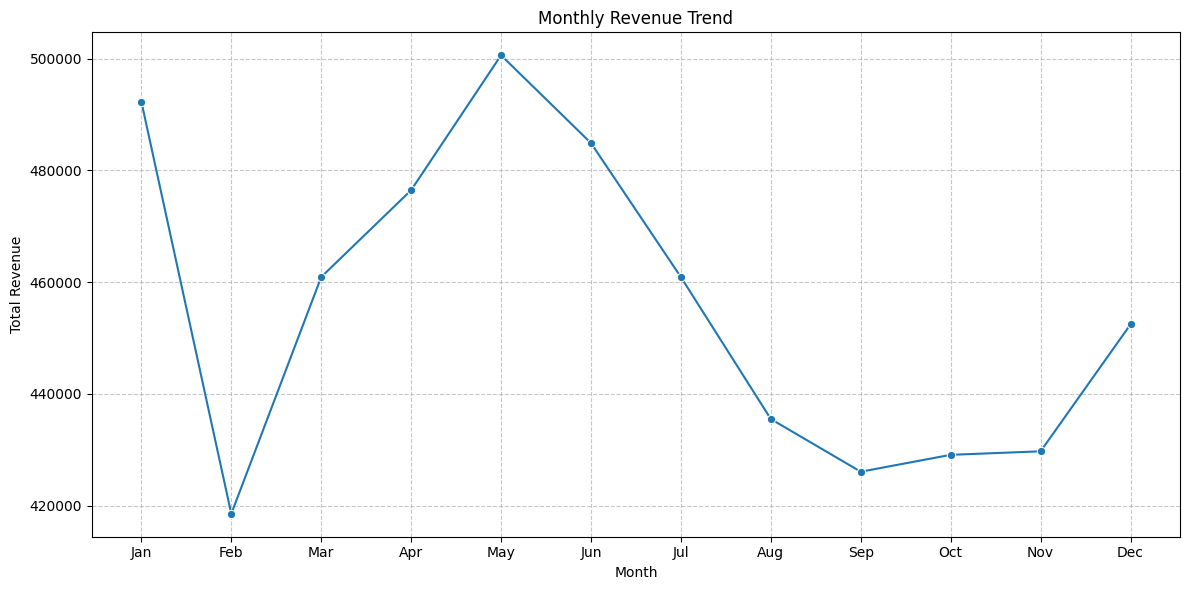

In [119]:
monthly_revenue = df.groupby('order_month_name')['revenue'].sum()

# To ensure correct chronological order, we can reindex if order_month_name is not already sorted numerically or set an appropriate order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_revenue = monthly_revenue.reindex(month_order, fill_value=0)

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', palette='viridis')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Revenue by Region

/tmp/ipykernel_1069/2525288602.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_revenue.index, y=region_revenue.values, palette='viridis')


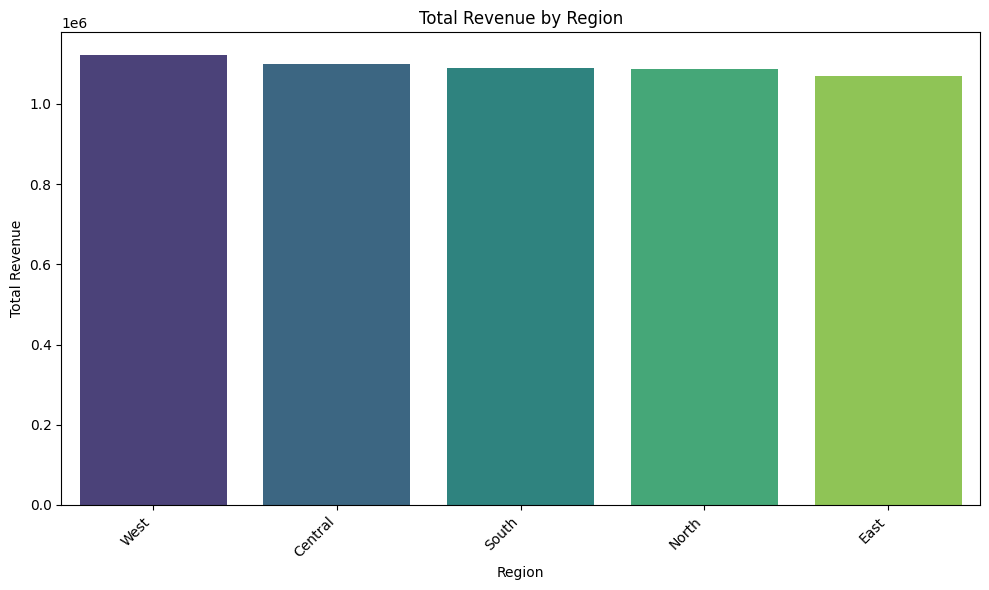

In [120]:
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_revenue.index, y=region_revenue.values, palette='viridis')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Customer Segment Distribution

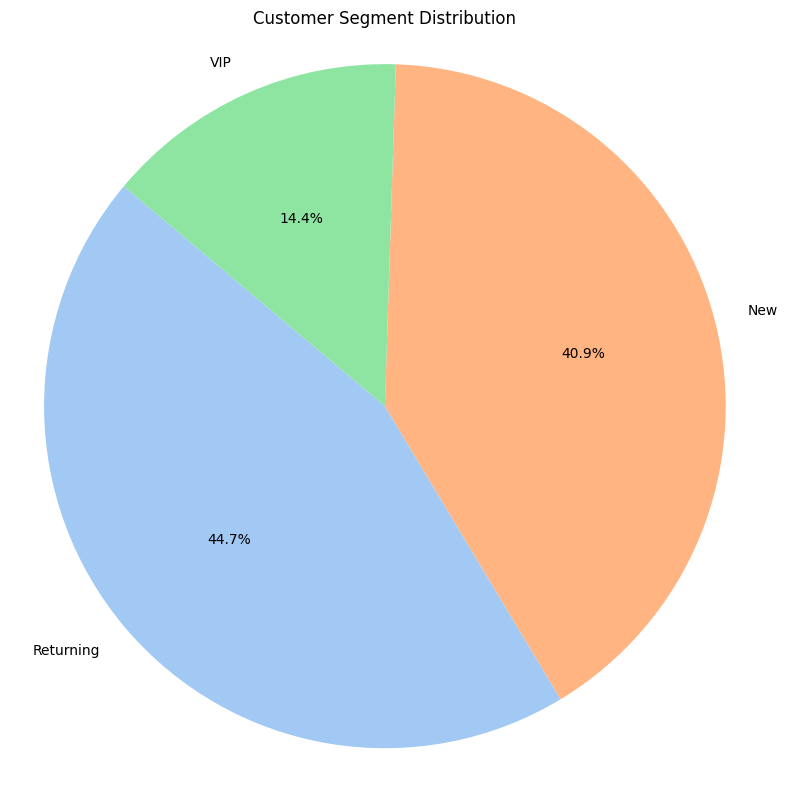

In [121]:
customer_segment_counts = df['customer_segment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(customer_segment_counts, labels=customer_segment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Customer Segment Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()